In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# Features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Train-test split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale all features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Train Logistic Regression
logreg = LogisticRegression(max_iter=500, solver='lbfgs', random_state=42)
logreg.fit(X_train_scaled, y_train)

# Predict probabilities
y_pred = logreg.predict(X_test_scaled)


In [55]:
# Classification metrics table
report_dict = classification_report(
    y_test, y_pred, target_names=["No Diabetes", "Diabetes"], output_dict=True
)
metrics_df = pd.DataFrame(report_dict).transpose()
metrics_df = metrics_df[['precision', 'recall', 'f1-score', 'support']].round(2)
metrics_df.index = ["No Diabetes", "Diabetes", "Accuracy", "Macro Avg", "Weighted Avg"]

# Display table
print("\nClassification Metrics Table:\n")
display(metrics_df.style.set_caption("Logistic Regression Metrics").set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
))


Classification Metrics Table:



,precision,recall,f1-score,support
No Diabetes,0.760000,0.730000,0.740000,7070.000000
Diabetes,0.740000,0.760000,0.750000,7069.000000
Accuracy,0.750000,0.750000,0.750000,0.750000
Macro Avg,0.750000,0.750000,0.750000,14139.000000
Weighted Avg,0.750000,0.750000,0.750000,14139.000000


In [56]:
# Inspect discriminant function coefficients
coef_df = pd.DataFrame(logreg.coef_, columns=X.columns, index=["No Diab vs Diab"])
print(coef_df)
print("\nIntercept:", logreg.intercept_[0])

                   HighBP  HighChol  CholCheck       BMI    Smoker    Stroke  \
No Diab vs Diab  0.362254  0.294816   0.207313  0.540393 -0.002295  0.044392   

                 HeartDiseaseorAttack  PhysActivity    Fruits   Veggies  ...  \
No Diab vs Diab              0.093862     -0.020678 -0.010518 -0.018648  ...   

                 AnyHealthcare  NoDocbcCost   GenHlth  MentHlth  PhysHlth  \
No Diab vs Diab       0.008651     0.005413  0.661685 -0.032786 -0.083532   

                 DiffWalk       Sex       Age  Education    Income  
No Diab vs Diab  0.045982  0.135212  0.429781  -0.031318 -0.121829  

[1 rows x 21 columns]

Intercept: -0.039129106727867596


Confusion Matrix:
 [[5145 1925]
 [1669 5400]]


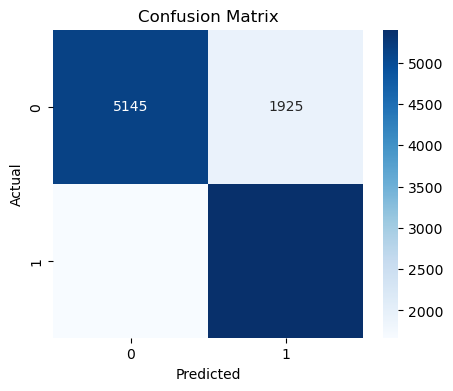

In [57]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

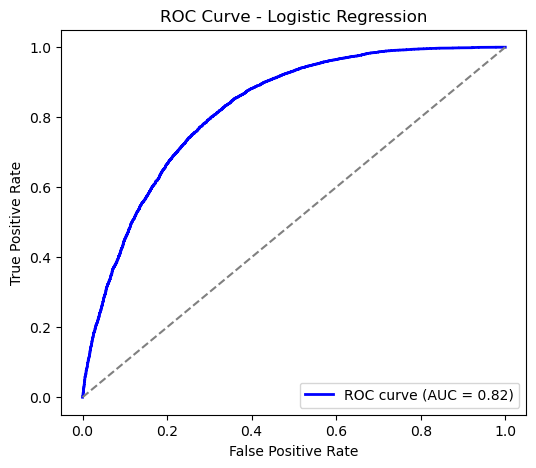

In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

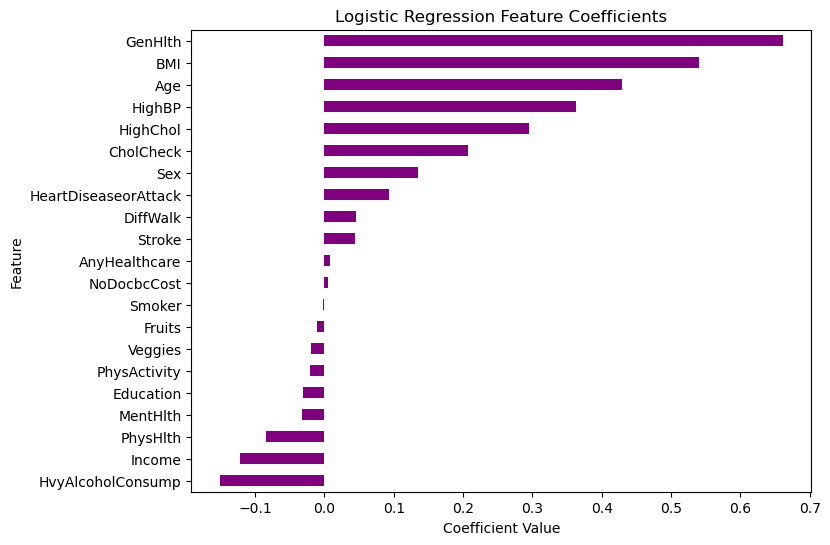

In [62]:
import numpy as np

coef = pd.Series(logreg.coef_[0], index=X.columns)
coef_sorted = coef.sort_values()

plt.figure(figsize=(8,6))
coef_sorted.plot(kind='barh', color='purple')
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()